In [43]:
from qiskit import QuantumCircuit, transpile,QuantumRegister
from qiskit.visualization import plot_bloch_multivector, plot_state_city
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.circuit.library import QFT
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_city
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
%matplotlib inline

In [44]:
def show_statevector(sv, title=""):
    print("\n" + "="*70)
    print(title)
    print("="*70)
    
    # Print non-zero amplitudes
    for i, amp in enumerate(sv.data):
        if abs(amp) > 1e-6:
            print(f"|{i:010b}>  {amp}")
            
    # Plot Bloch vectors
    fig = plot_bloch_multivector(sv)
    fig.suptitle(title)
    plt.show()


Figure(287.496x451.5)


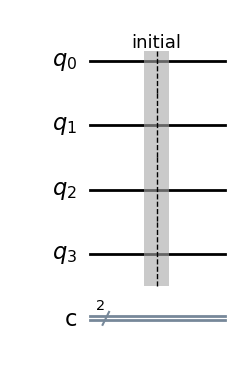


Intial:
|0000000000>  (1+0j)


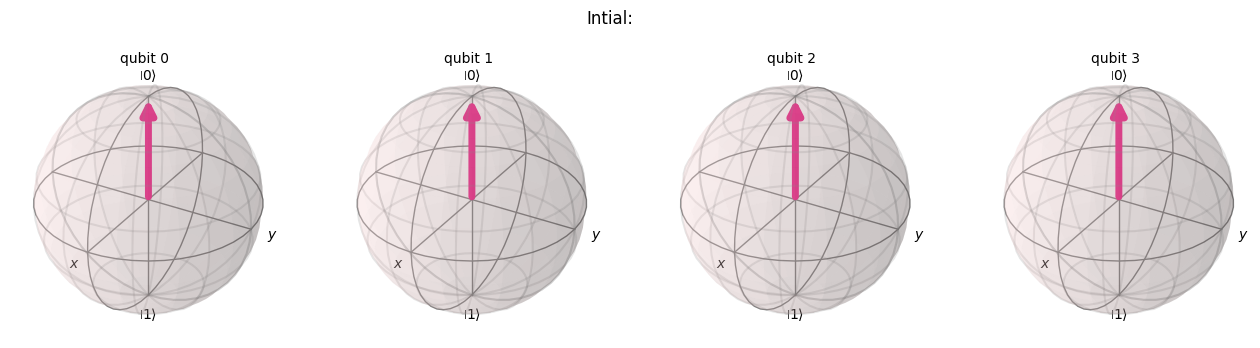

In [45]:
#STEP 1 Create 4 qubit circuit
qc = QuantumCircuit(4,2)
qc.barrier(label="initial")
#Qubit labeling
'''
q0 → particle 1
q1 → particle 2
q2 → particle 3
q3 → particle 4
'''
# Simulate 
state_vector= Statevector.from_instruction(qc)
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "Intial:")

Figure(621.941x451.5)


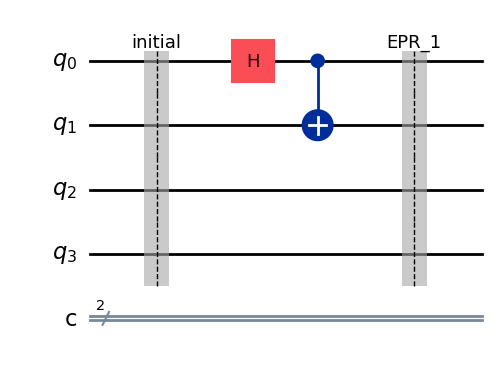


After First EPR_1 (q0 and q1):∣Φ+⟩12=1/√2(∣00⟩+∣11⟩)
|0000000000>  (0.7071067811865475+0j)
|0000000011>  (0.7071067811865475+0j)


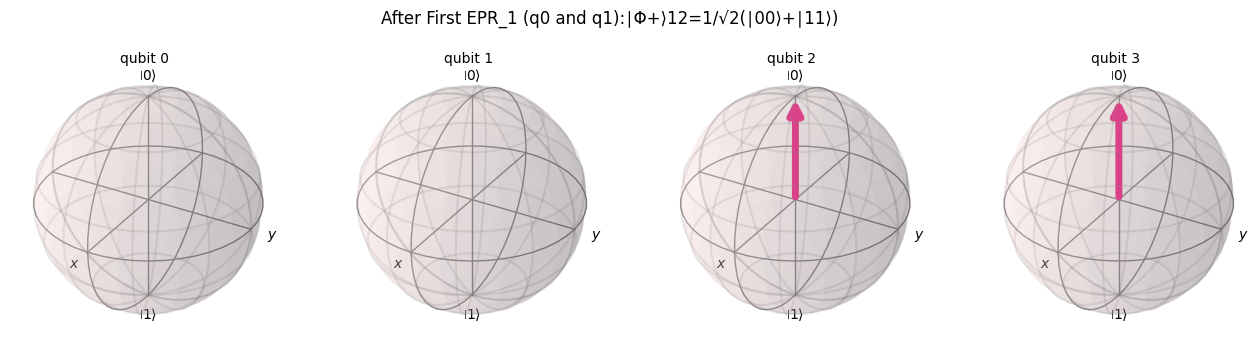

In [46]:
#Step2 Create First EPR pair between(1,2)  where q0 and q1 are entangled
qc.h(0) 
qc.cx(0,1)     
qc.barrier(label="EPR_1")
# Simulate 
state_vector= Statevector.from_instruction(qc)
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "After First EPR_1 (q0 and q1):∣Φ+⟩12=1/√2(∣00⟩+∣11⟩)")

Figure(956.385x451.5)


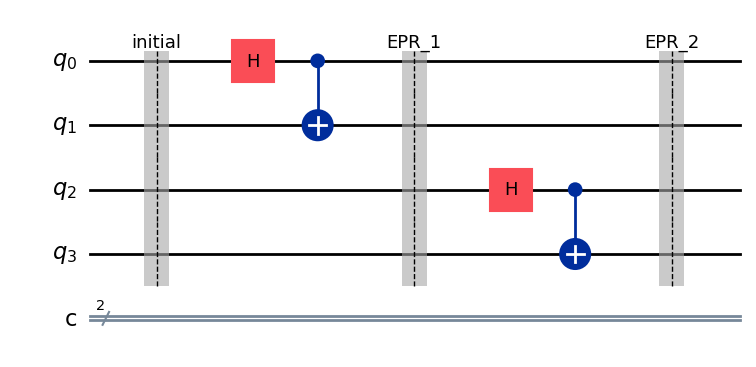


After Second EPR_2(q2 and q3):∣Φ+⟩34=1/√2(∣01⟩+∣10⟩)
|0000000000>  (0.4999999999999999+0j)
|0000000011>  (0.4999999999999999+0j)
|0000001100>  (0.4999999999999999+0j)
|0000001111>  (0.4999999999999999+0j)


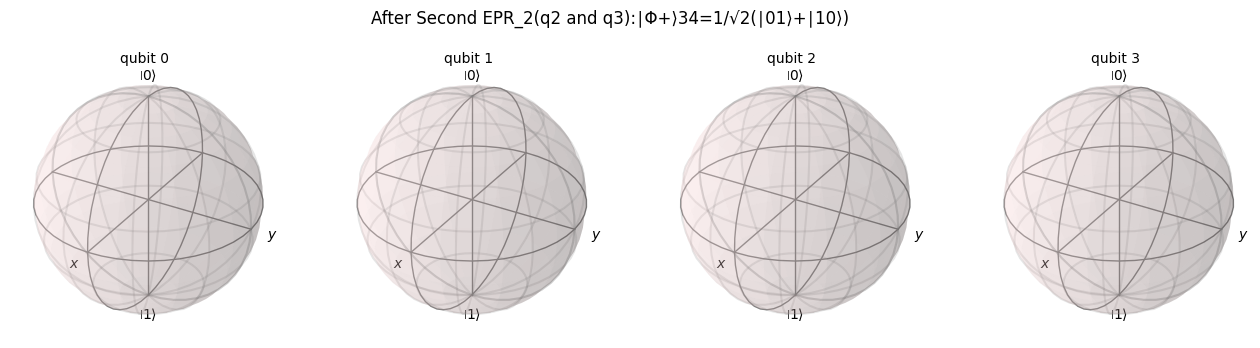

In [47]:
#Step3 Create Second EPR pair between(3,4)  where q2 and q2 are entangled
qc.h(2) 
qc.cx(2,3)
qc.barrier(label="EPR_2")
# Simulate 
state_vector= Statevector.from_instruction(qc)
print(qc.draw('mpl'))
plt.show()
show_statevector(state_vector, "After Second EPR_2(q2 and q3):∣Φ+⟩34=1/√2(∣01⟩+∣10⟩)")

In [48]:
print("Total Joint State=>∣Ψ0⟩=∣Φ+⟩12⊗∣Φ+⟩34 =1/2(∣0000⟩+∣0011⟩+∣1100⟩+∣1111⟩)")

Total Joint State=>∣Ψ0⟩=∣Φ+⟩12⊗∣Φ+⟩34 =1/2(∣0000⟩+∣0011⟩+∣1100⟩+∣1111⟩)


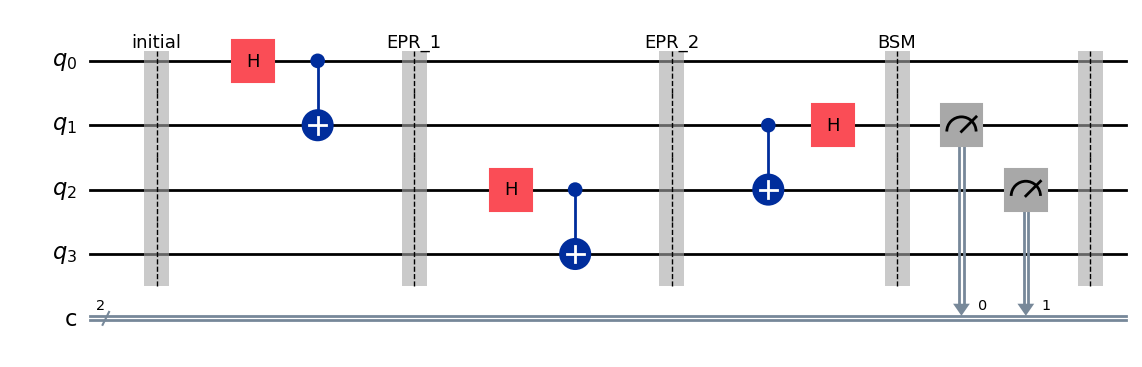

In [49]:
#STEP 3 :Perform Bell measurement on qubits (2,3) i.e; (q2,q3)
'''
order of operation 
1.CNOT
2.Hadamard
3.Measurement
'''
qc.cx(1,2)
qc.h(1)
qc.barrier(label="BSM")
qc.measure(1,0)
qc.measure(2,1)

#Now the Bell state of qubits (1,2) is measured. This projects qubits (0,3) into an entangled state.
qc.barrier(label="")
qc.draw('mpl')
#print(qc.draw('mpl'))
plt.show()  

In [50]:
print("After CNOT(q1,q2)=CNOT(2,3)qubit=> ∣Ψ1⟩=1/2(∣0000⟩+∣0011⟩+∣1110⟩+∣1101⟩)")
print("After Hadamard on (q1)=Hadamard on qubit 2=> ∣Ψ2⟩=1/2√2(∣0000⟩+∣0100⟩+∣0011⟩+∣0111⟩+∣1010⟩−∣1110⟩+∣1001⟩−∣1101⟩)")
print("After BSM=>CNOT(q1,q2)+ Hadamard on (q1)=>∣Ψ2⟩=1/2√2(∣0000⟩+∣0100⟩+∣0011⟩+∣0111⟩+∣1010⟩−∣1110⟩+∣1001⟩−∣1101⟩)")

After CNOT(q1,q2)=CNOT(2,3)qubit=> ∣Ψ1⟩=1/2(∣0000⟩+∣0011⟩+∣1110⟩+∣1101⟩)
After Hadamard on (q1)=Hadamard on qubit 2=> ∣Ψ2⟩=1/2√2(∣0000⟩+∣0100⟩+∣0011⟩+∣0111⟩+∣1010⟩−∣1110⟩+∣1001⟩−∣1101⟩)
After BSM=>CNOT(q1,q2)+ Hadamard on (q1)=>∣Ψ2⟩=1/2√2(∣0000⟩+∣0100⟩+∣0011⟩+∣0111⟩+∣1010⟩−∣1110⟩+∣1001⟩−∣1101⟩)


In [51]:
#Group by measurement results (q2,q3) => which make entanglement between (qo,q3)=> entanglement between (fisrt,fourth)qubit

print("(q2,q3)=00=∣Φ+⟩14")
print("(q2,q3)=01==∣Ψ+⟩14")
print("(q2,q3)=10==∣Φ−⟩14")
print("(q2,q3)=11==∣Ψ−⟩14")


(q2,q3)=00=∣Φ+⟩14
(q2,q3)=01==∣Ψ+⟩14
(q2,q3)=10==∣Φ−⟩14
(q2,q3)=11==∣Ψ−⟩14


In [52]:
#Verify Entanglement with Statevector(Before measurement we can check the state)=> mathematically proves entanglement swapping
qc2 = QuantumCircuit(4)
#EPR_1
qc2.h(0)
qc2.cx(0,1)
#EPR_2
qc2.h(2)
qc2.cx(2,3)
#BSM
qc2.cx(1,2)
qc2.h(1)

state = Statevector.from_instruction(qc2)

print("State_vector=superposition of four Bell states=16 combinations =|0000>|0001>|0010>|0011>...|1111>\n",state)

State_vector=superposition of four Bell states=16 combinations =|0000>|0001>|0010>|0011>...|1111>
 Statevector([ 0.35355339+0.j,  0.        +0.j,  0.35355339+0.j,
              0.        +0.j,  0.        +0.j,  0.35355339+0.j,
              0.        +0.j, -0.35355339+0.j,  0.        +0.j,
              0.35355339+0.j,  0.        +0.j, -0.35355339+0.j,
              0.35355339+0.j,  0.        +0.j,  0.35355339+0.j,
              0.        +0.j],
            dims=(2, 2, 2, 2))


In [53]:
#Explanation of the above Block
print("initially=>|q0,q1,q2,q3>=|0000>")
print("\n")
print("Create EPR_1")
print("Hadamard acting on q0=>(∣Ψ1⟩=1/√2(∣0000⟩+∣1000⟩")
print("Apply CNOT(q0→q1)=Apply CNOT(0→1)=∣Ψ2⟩=1/√2(∣0000⟩+∣1100⟩)=∣Φ+⟩01⊗∣00⟩23=First Bell pair created.")
print("\n")
print("Create EPR_2")
print("Hadamard acting on q2=>(∣Ψ3⟩=1/2(∣0000⟩+∣0010⟩+∣1100⟩+∣1110⟩)")
print("Apply CNOT(q2→q3)=Apply CNOT(2→3)=∣Ψ4⟩=1/2(∣0000⟩+∣0011⟩+∣1100⟩+∣1111⟩)=∣Φ+⟩01⊗∣Φ+⟩23=First Bell pair created.")
print("\n")
print("Bell_State_Measurement")
print("Apply CNOT(q1→q2)=Apply CNOT(1→2)=∣Ψ5⟩=1/2(∣0000⟩+∣0011⟩+∣1110⟩+∣1101⟩)")
print("Apply Hadamard on qubit 1(q1)=>∣Ψ7⟩=1/2(∣Φ+⟩12∣Φ+⟩03+∣Φ−⟩12∣Φ−⟩03+∣Ψ+⟩12∣Ψ+⟩03+∣Ψ−⟩12∣Ψ−⟩03")

initially=>|q0,q1,q2,q3>=|0000>


Create EPR_1
Hadamard acting on q0=>(∣Ψ1⟩=1/√2(∣0000⟩+∣1000⟩
Apply CNOT(q0→q1)=Apply CNOT(0→1)=∣Ψ2⟩=1/√2(∣0000⟩+∣1100⟩)=∣Φ+⟩01⊗∣00⟩23=First Bell pair created.


Create EPR_2
Hadamard acting on q2=>(∣Ψ3⟩=1/2(∣0000⟩+∣0010⟩+∣1100⟩+∣1110⟩)
Apply CNOT(q2→q3)=Apply CNOT(2→3)=∣Ψ4⟩=1/2(∣0000⟩+∣0011⟩+∣1100⟩+∣1111⟩)=∣Φ+⟩01⊗∣Φ+⟩23=First Bell pair created.


Bell_State_Measurement
Apply CNOT(q1→q2)=Apply CNOT(1→2)=∣Ψ5⟩=1/2(∣0000⟩+∣0011⟩+∣1110⟩+∣1101⟩)
Apply Hadamard on qubit 1(q1)=>∣Ψ7⟩=1/2(∣Φ+⟩12∣Φ+⟩03+∣Φ−⟩12∣Φ−⟩03+∣Ψ+⟩12∣Ψ+⟩03+∣Ψ−⟩12∣Ψ−⟩03


{'00': 291, '01': 245, '11': 225, '10': 263}


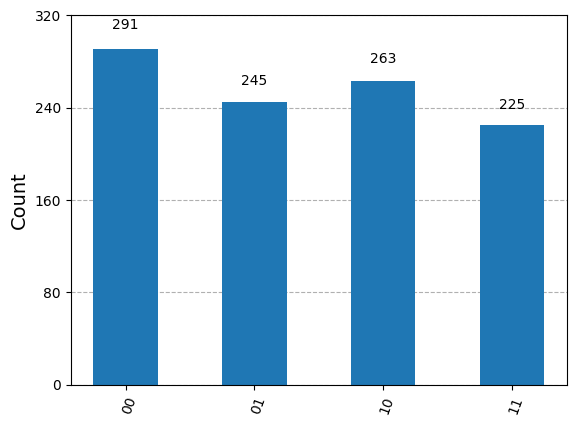

In [54]:
simulator = AerSimulator()

compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
plt.show()